# Objetivo do trabalho
Uso do alexNet para detecção de cancer de intestino
- Dateset: DykeF/NCTCRCHE100K
- 100K imagens de treinamento e 7180 para teste
- resolução transformadas: 150 x 150 pixeis

In [1]:
import tqdm
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import kagglehub
import shutil
from typing import Tuple
from PIL import Image
from imblearn.combine import SMOTETomek
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import albumentations as A
import cv2
from albumentations.pytorch import ToTensorV2
import os
import datetime
import torchvision
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tabulate import tabulate
import seaborn as sns
import copy

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"Using: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")
else:
    print("CUDA is not available. Using CPU.")

Using: NVIDIA A100-SXM4-40GB
CUDA: 12.6


In [3]:
!pip install -q datasets==2.14.6

In [6]:
from datasets import load_dataset
ds = load_dataset("DykeF/NCTCRCHE100K")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train_nonorm split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


In [12]:
ds


DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'file'],
        num_rows: 100000
    })
    train_nonorm: Dataset({
        features: ['image', 'label', 'file'],
        num_rows: 100000
    })
    validation: Dataset({
        features: ['image', 'label', 'file'],
        num_rows: 7180
    })
})

In [18]:
splited = ds["train"].train_test_split(test_size=0.2, seed=42)
dataset_train = splited["train"]
dataset_validation = splited["test"]
dataset_test = ds["validation"]

In [23]:
set(dataset_train["label"])

{'ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM'}

In [25]:
cancer_classes = {"TUM"}
normal_classes = {"ADI", "BACK", "DEB", "LYM", "MUC", "MUS", "NORM", "STR"}

In [19]:

print(f"\nNumber of images in training dataset: {len(dataset_train)}")
print(f"Number of images in validation dataset: {len(dataset_validation)}")
print(f"Number of images in test dataset: {len(dataset_test)}")



Number of images in training dataset: 80000
Number of images in validation dataset: 20000
Number of images in test dataset: 7180


In [26]:
def keep_valid(example):
    return example["label"] in cancer_classes or example["label"] in normal_classes

dataset_train = dataset_train.filter(keep_valid)
dataset_validation = dataset_validation.filter(keep_valid)
dataset_test = dataset_test.filter(keep_valid)

print(f"\nNumber of images in training dataset: {len(dataset_train)}")
print(f"Number of images in validation dataset: {len(dataset_validation)}")
print(f"Number of images in test dataset: {len(dataset_test)}")


Filter:   0%|          | 0/80000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/20000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/7180 [00:00<?, ? examples/s]


Number of images in training dataset: 80000
Number of images in validation dataset: 20000
Number of images in test dataset: 7180


In [28]:
def to_binary(example):
    if example["label"] == "TUM":
        example["label"] = 1
    else:
        example["label"] = 0
    return example

In [29]:
dataset_train = dataset_train.map(to_binary)
dataset_validation = dataset_validation.map(to_binary)
dataset_test = dataset_test.map(to_binary)

Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7180 [00:00<?, ? examples/s]

In [30]:
set(dataset_train["label"])

{0, 1}

In [42]:
print(dataset_train.features)

{'image': Image(decode=True, id=None), 'label': Value(dtype='int64', id=None), 'file': Value(dtype='string', id=None)}


In [ ]:
class NCTCRCHE100KDatasetMemory(Dataset):
    def __init__(self, hf_dataset, transforms=None):
        self.transforms = transforms

        self.images = []
        self.labels = []

        for item in hf_dataset:
            image = item["image"].convert("RGB")
            image = np.array(image)

            self.images.append(image)
            self.labels.append(item["label"])

        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transforms:
            image = self.transforms(image=image)["image"]

        return image, label
    
class NCTCRCHE100KDatasetConfig:
    VAL_SIZE = 0.2
    SEED = 0x40

    TEST_TRANSFORMS = A.Compose([
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

    TRAIN_TRANSFORMS = A.Compose([
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])


def get_dataloaders(df_train, df_validation, df_test, batch_size=64, num_workers=2):

    dataset_train = NCTCRCHE100KDatasetMemory(df_train, transforms=NCTCRCHE100KDatasetConfig.TRAIN_TRANSFORMS)
    dataset_validation = NCTCRCHE100KDatasetMemory(df_validation, transforms=NCTCRCHE100KDatasetConfig.TEST_TRANSFORMS)
    dataset_test = NCTCRCHE100KDatasetMemory(df_test, transforms=NCTCRCHE100KDatasetConfig.TEST_TRANSFORMS)

    train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=num_workers)
    val_loader = DataLoader(dataset_validation, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=num_workers)
    test_loader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=num_workers)

    return train_loader, val_loader, test_loader

In [44]:
batch_size = 64
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(dataset_train, dataset_validation, dataset_test, batch_size, 2)

### hiperparametros
- numero de canais de entrada: 3
- numero de classes de saída: 2
- taxa de aprendizado: 1e-4
- otimizador: Adam
- número de épocas: 50

In [45]:
in_channels = 3
output_features = 2
learning_rate = 1e-4

In [46]:
model = torchvision.models.alexnet(num_classes=output_features)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


### Treinamento

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [48]:
criterion = torch.nn.CrossEntropyLoss()

def train_model(model, dataloader_train, dataloader_validation, optimizer, epochs = 10, patience = 0, scheduler = None, drive_path = '/content/drive/MyDrive/Machine Learning/Resultados TCC/models/NCTCRCHE100K'):
    model = model.to("cuda")
    device = "cuda"
    train_losses = []
    val_losses = []
    best_loss = float("inf")
    best_model_state = None
    epochs_no_improve = 0
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_loss_validation = 0

        for images, labels in dataloader_train:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size()[0]

        with torch.no_grad():
            model.eval() 

            for images, labels in dataloader_validation:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss_validation += loss.item() * images.size()[0]
            

        avg_train_loss = total_loss / len(dataloader_train.dataset)
        avg_val_loss = total_loss_validation / len(dataloader_validation.dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if scheduler is not None:
            scheduler.step()

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), f"{model.__class__.__name__}.pt")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        if patience > 0 and epochs_no_improve >= patience:
            print(f"\nEarly stopping ativado! Melhor Val Loss: {best_loss:.4f}")
            break
    
    model.load_state_dict(best_model_state)
    os.makedirs(drive_path, exist_ok=True)
    best_path = drive_path + f"/{model.__class__.__name__}_best.pt"
    torch.save(best_model_state, best_path)
    return train_losses, val_losses, model

def test_model(model, device, dataloader_test):
    model = model.to(device)
    model.eval()  # Modo de avaliação
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader_test:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Cálculo das métricas
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"Acurácia: {acc:.4f}")
    print(f"Precisão (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"F1-score (weighted): {f1:.4f}")
    print("Matriz de Confusão:")
    print(cm)

    return acc, precision, recall, f1, cm


In [49]:
train_losses, val_losses, best_model = train_model(model, dataloader_train, dataloader_validation, optimizer, 50, 15)

Epoch 1/50 | Train Loss: 0.1458 | Val Loss: 0.0797
Epoch 2/50 | Train Loss: 0.0667 | Val Loss: 0.0498
Epoch 3/50 | Train Loss: 0.0476 | Val Loss: 0.0416
Epoch 4/50 | Train Loss: 0.0387 | Val Loss: 0.0501
Epoch 5/50 | Train Loss: 0.0308 | Val Loss: 0.0321
Epoch 6/50 | Train Loss: 0.0252 | Val Loss: 0.0986
Epoch 7/50 | Train Loss: 0.0217 | Val Loss: 0.0631
Epoch 8/50 | Train Loss: 0.0189 | Val Loss: 0.0370
Epoch 9/50 | Train Loss: 0.0164 | Val Loss: 0.0386
Epoch 10/50 | Train Loss: 0.0140 | Val Loss: 0.0386
Epoch 11/50 | Train Loss: 0.0121 | Val Loss: 0.0410
Epoch 12/50 | Train Loss: 0.0109 | Val Loss: 0.0502
Epoch 13/50 | Train Loss: 0.0095 | Val Loss: 0.0585
Epoch 14/50 | Train Loss: 0.0086 | Val Loss: 0.0612
Epoch 15/50 | Train Loss: 0.0067 | Val Loss: 0.0476
Epoch 16/50 | Train Loss: 0.0069 | Val Loss: 0.0905
Epoch 17/50 | Train Loss: 0.0076 | Val Loss: 0.0360
Epoch 18/50 | Train Loss: 0.0062 | Val Loss: 0.0701
Epoch 19/50 | Train Loss: 0.0054 | Val Loss: 0.0494
Epoch 20/50 | Train L

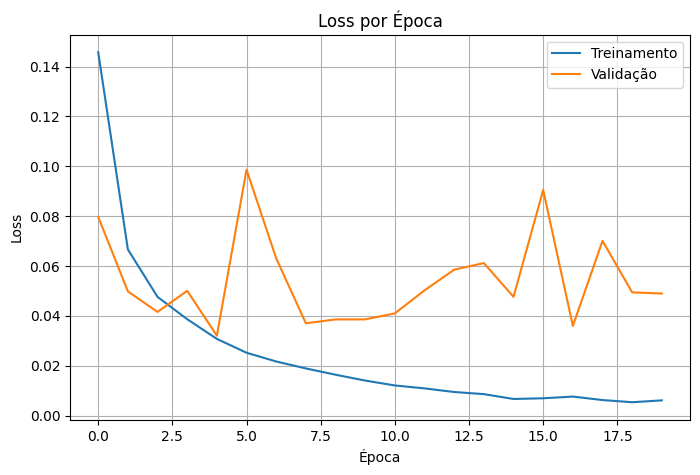

In [50]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [51]:
acc, precision, recall, f1, cm = test_model(model, "cuda", dataloader_test)

Acurácia: 0.9779
Precisão (weighted): 0.9777
Recall (weighted): 0.9779
F1-score (weighted): 0.9776
Matriz de Confusão:
[[5903   44]
 [ 115 1118]]


In [52]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │  0.9779 │
├─────────────────────┼─────────┤
│ Precisão (weighted) │  0.9777 │
├─────────────────────┼─────────┤
│ Recall (weighted)   │  0.9779 │
├─────────────────────┼─────────┤
│ F1-score (weighted) │  0.9776 │
╘═════════════════════╧═════════╛


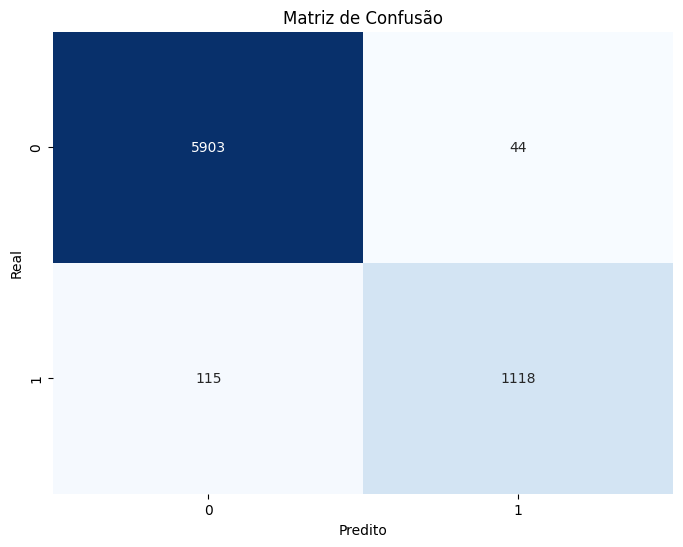

In [53]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()